# Backtesting — FIFA World Cup 2022 (Qatar)
Evaluamos Poisson, XGBoost y Ensemble entrenados **sin ver ningún partido del torneo**.
Test set: 64 partidos, 20 nov – 18 dic 2022.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve

from src.evaluation.backtest import run_backtest, compute_metrics

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

FEATURES_PATH = '../data/processed/features.csv'

## 1. Entrenar y predecir

In [2]:
results, poisson_model, xgb_pipeline = run_backtest(FEATURES_PATH, test_year=2022)
print(f"\nResultados generados: {len(results)} partidos")

  Cutoff           : 2022-11-20  (day tournament starts)
  Train (Poisson)  : 26,992 matches
  Train (XGBoost)  : 15,968 matches
  Test             : 64 matches  (FIFA World Cup 2022)

  Fitting Poisson ...


  Fitting XGBoost ...


CV accuracy: 0.565 ± 0.024



Resultados generados: 64 partidos


## 2. Metricas resumen por modelo

In [3]:
metrics_rows = [compute_metrics(results, m) for m in ('poisson', 'xgb', 'ens')]
metrics_df   = pd.DataFrame(metrics_rows).set_index('model')

tbl = metrics_df[['accuracy','log_loss','brier','exact_score_acc','goal_mae']].copy()
tbl.columns = ['Accuracy','Log-loss','Brier','Score exacto','MAE goles']

display(
    tbl.style
    .format({
        'Accuracy':     '{:.1%}',
        'Log-loss':     '{:.3f}',
        'Brier':        '{:.3f}',
        'Score exacto': lambda x: f'{x:.1%}' if pd.notna(x) else '—',
        'MAE goles':    lambda x: f'{x:.2f}' if pd.notna(x) else '—',
    })
    .background_gradient(subset=['Accuracy'], cmap='Greens', vmin=0.3, vmax=0.6)
    .background_gradient(subset=['Log-loss','Brier'], cmap='Reds_r', vmin=0.6, vmax=1.2)
    .set_properties(**{'font-size': '12px', 'text-align': 'center'})
)

,Accuracy,Log-loss,Brier,Score exacto,MAE goles
model,,,,,
poisson,46.9%,1.121,0.656,6.2%,0.97
xgb,50.0%,1.162,0.669,—,—
ens,46.9%,1.107,0.646,—,—


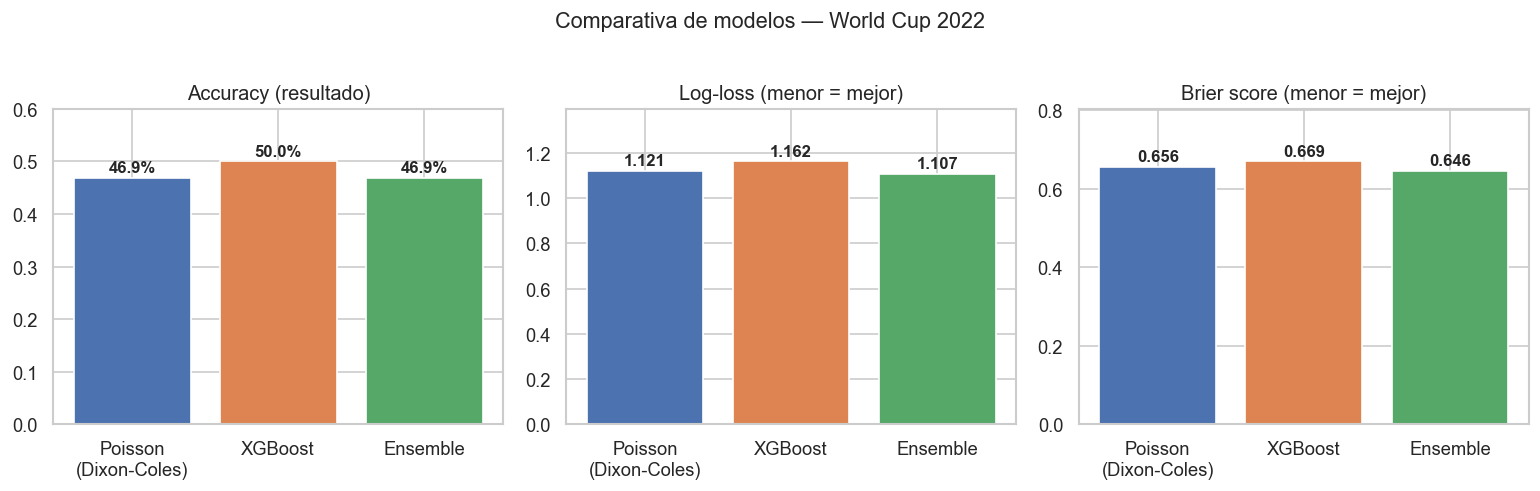

In [4]:
# Bar chart — accuracy comparison
accs = {m: compute_metrics(results, m)['accuracy'] for m in ('poisson','xgb','ens')}
labels = {'poisson': 'Poisson\n(Dixon-Coles)', 'xgb': 'XGBoost', 'ens': 'Ensemble'}
colors = ['#4c72b0', '#dd8452', '#55a868']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

metric_data = [
    ('accuracy', 'Accuracy (resultado)', '{:.1%}'),
    ('log_loss', 'Log-loss (menor = mejor)', '{:.3f}'),
    ('brier',    'Brier score (menor = mejor)', '{:.3f}'),
]

for ax, (key, title, fmt) in zip(axes, metric_data):
    vals = [compute_metrics(results, m)[key] for m in ('poisson','xgb','ens')]
    bars = ax.bar([labels[m] for m in ('poisson','xgb','ens')], vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Comparativa de modelos — World Cup 2022', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Confusion matrix por modelo

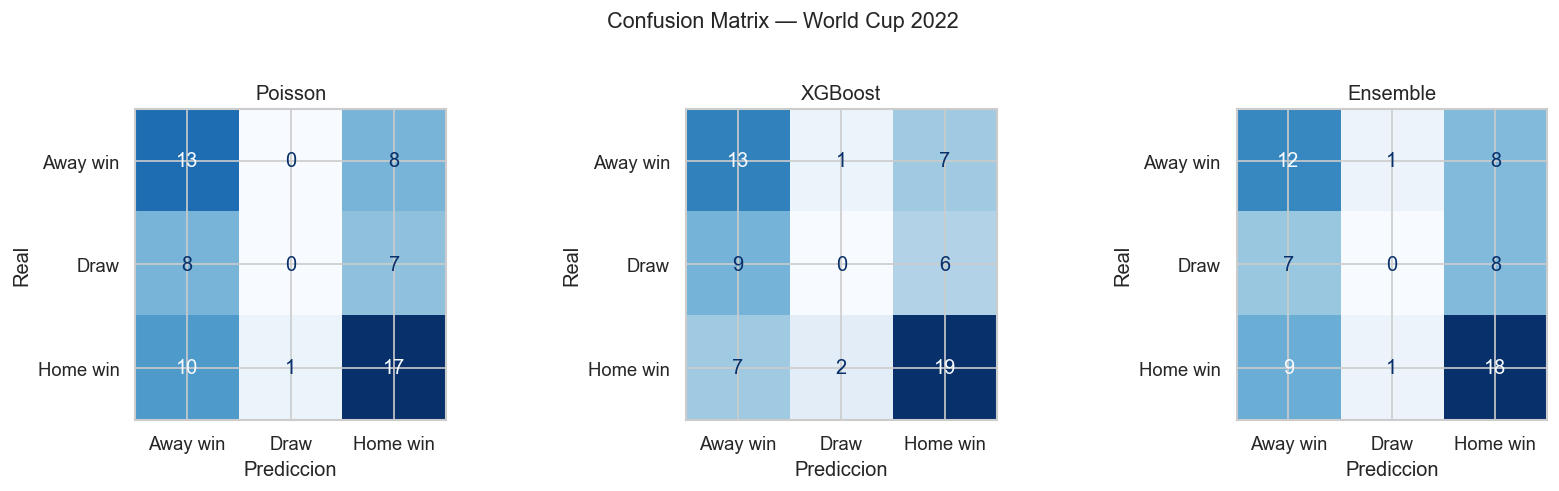

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
model_names = {'poisson': 'Poisson', 'xgb': 'XGBoost', 'ens': 'Ensemble'}
class_labels = ['Away win', 'Draw', 'Home win']

for ax, model in zip(axes, ('poisson', 'xgb', 'ens')):
    cm = confusion_matrix(results['actual_result'], results[f'pred_{model}'], labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model_names[model])
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.suptitle('Confusion Matrix — World Cup 2022', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Calibracion de probabilidades

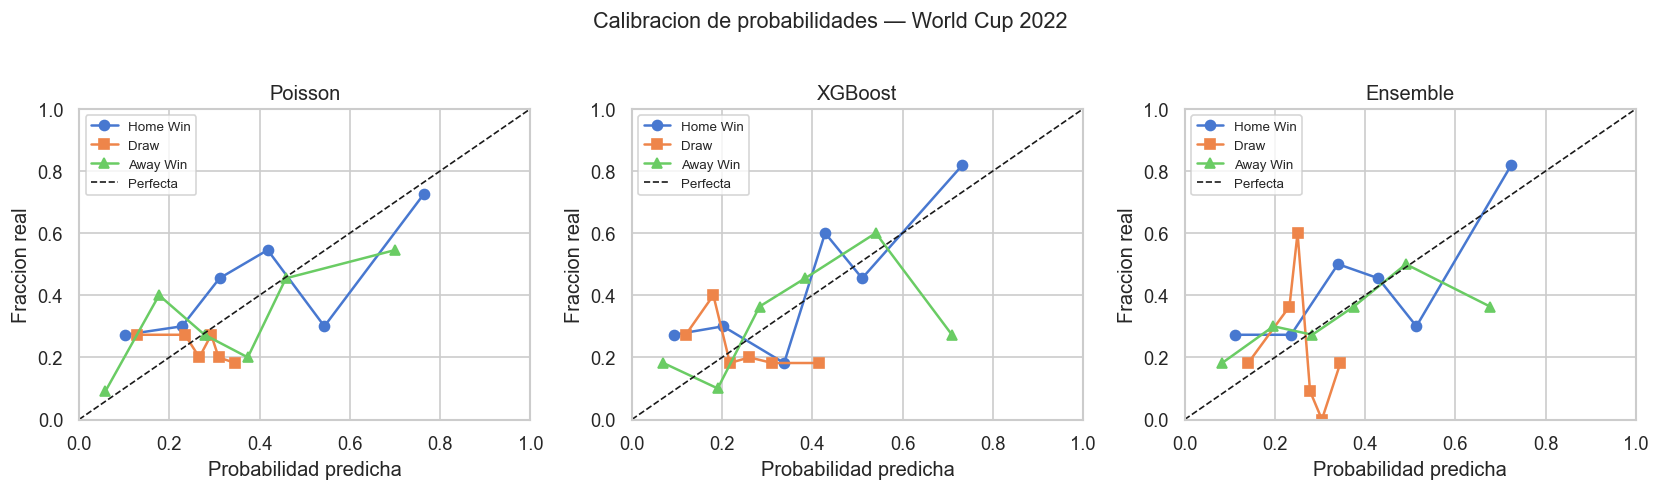

In [6]:
# Calibration: predicted p(home_win) vs actual fraction home wins
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model, color in zip(axes, ('poisson','xgb','ens'), colors):
    for outcome, col, marker in [
        ('home_win', 'p_home', 'o'),
        ('draw',     'p_draw', 's'),
        ('away_win', 'p_away', '^'),
    ]:
        outcome_idx = {'home_win':2, 'draw':1, 'away_win':0}[outcome]
        y_true_bin = (results['actual_result'] == outcome_idx).astype(int).values
        y_prob = results[f'{col}_{model}'].values
        if y_prob.max() > y_prob.min():  # avoid flat curves
            frac_pos, mean_pred = calibration_curve(y_true_bin, y_prob, n_bins=6, strategy='quantile')
            ax.plot(mean_pred, frac_pos, marker=marker, lw=1.5,
                    label=outcome.replace('_',' ').title())
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfecta')
    ax.set_title(model_names[model])
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Fraccion real')
    ax.legend(fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('Calibracion de probabilidades — World Cup 2022', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Prediccion de score exacto (Poisson)

MAE goles local     : 1.08
MAE goles visitante : 0.86
Score exacto acertado: 6.2%



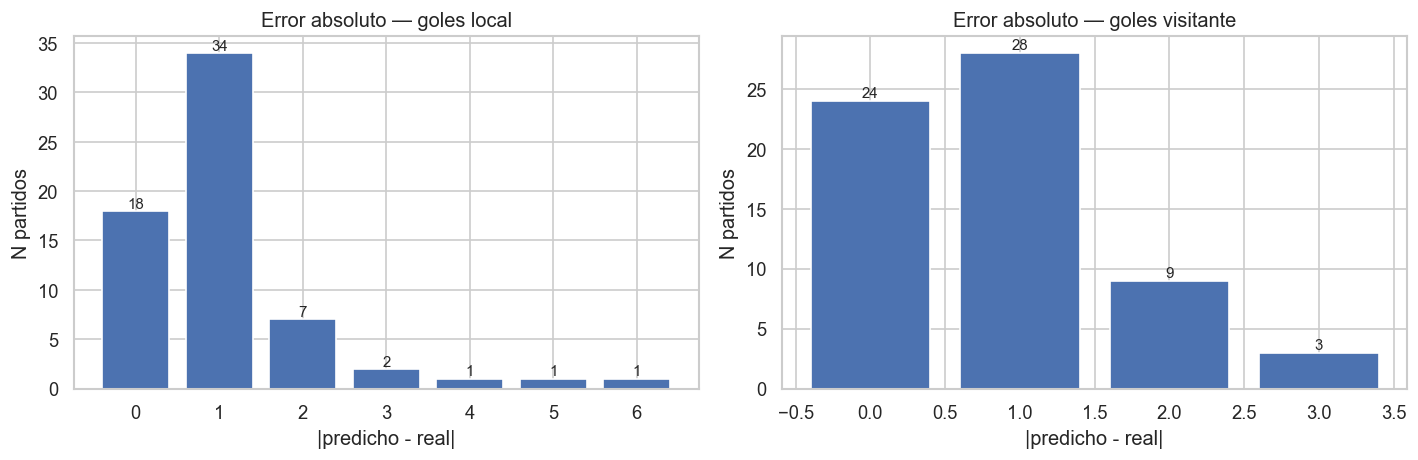

In [7]:
# MAE por goles local y visitante
results['err_home'] = (results['exact_home_poisson'] - results['home_score']).abs()
results['err_away'] = (results['exact_away_poisson'] - results['away_score']).abs()

print(f"MAE goles local     : {results['err_home'].mean():.2f}")
print(f"MAE goles visitante : {results['err_away'].mean():.2f}")
print(f"Score exacto acertado: {((results['err_home']==0) & (results['err_away']==0)).mean():.1%}")
print()

# Distribucion de errores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], 'err_home', 'Error absoluto — goles local'),
    (axes[1], 'err_away', 'Error absoluto — goles visitante'),
]:
    cnt = results[col].value_counts().sort_index()
    ax.bar(cnt.index, cnt.values, color='#4c72b0')
    ax.set_title(title)
    ax.set_xlabel('|predicho - real|')
    ax.set_ylabel('N partidos')
    for x, v in zip(cnt.index, cnt.values):
        ax.text(x, v + 0.3, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

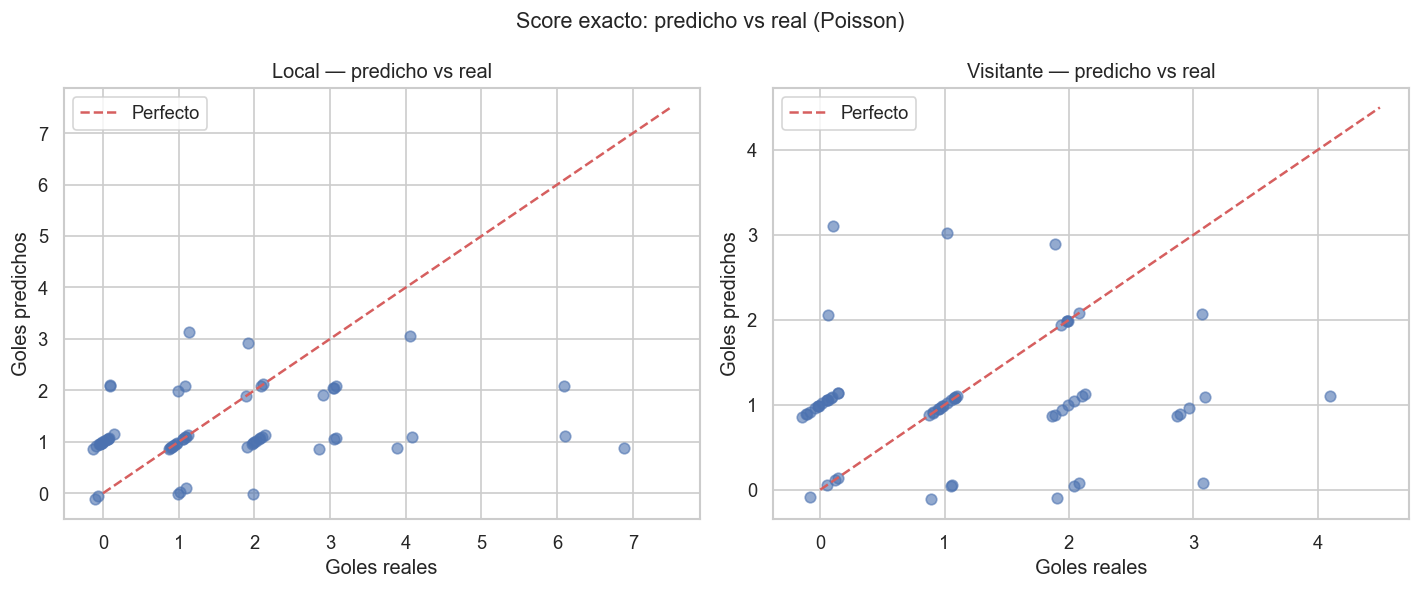

In [8]:
# Scatter: score real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred_col, real_col, title in [
    (axes[0], 'exact_home_poisson', 'home_score', 'Local — predicho vs real'),
    (axes[1], 'exact_away_poisson', 'away_score', 'Visitante — predicho vs real'),
]:
    # jitter for visibility
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(results))
    ax.scatter(results[real_col] + jitter, results[pred_col] + jitter,
               alpha=0.6, color='#4c72b0', s=40)
    lim = max(results[[pred_col, real_col]].max()) + 0.5
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfecto')
    ax.set_title(title)
    ax.set_xlabel('Goles reales')
    ax.set_ylabel('Goles predichos')
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle('Score exacto: predicho vs real (Poisson)', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Tabla completa — match a match

In [9]:
outcome_label = {0: 'Away', 1: 'Draw', 2: 'Home'}

table = results[[
    'date','home_team','away_team','home_score','away_score',
    'actual_result','pred_ens','pred_poisson','pred_xgb',
    'exact_home_poisson','exact_away_poisson',
    'p_home_ens','p_draw_ens','p_away_ens'
]].copy()

table['score_real']   = table['home_score'].astype(str) + '-' + table['away_score'].astype(str)
table['score_pred']   = table['exact_home_poisson'].astype(str) + '-' + table['exact_away_poisson'].astype(str)
table['result_real']  = table['actual_result'].map(outcome_label)
table['ens_ok']       = (table['actual_result'] == table['pred_ens']).map({True:'✓', False:'✗'})
table['poisson_ok']   = (table['actual_result'] == table['pred_poisson']).map({True:'✓', False:'✗'})
table['score_ok']     = ((table['exact_home_poisson'] == table['home_score']) &
                         (table['exact_away_poisson'] == table['away_score'])).map({True:'✓', False:'✗'})
table['p_home_ens']   = table['p_home_ens'].map('{:.0%}'.format)
table['p_draw_ens']   = table['p_draw_ens'].map('{:.0%}'.format)
table['p_away_ens']   = table['p_away_ens'].map('{:.0%}'.format)

display_cols = [
    'date','home_team','away_team','score_real','score_pred',
    'result_real','ens_ok','poisson_ok','score_ok',
    'p_home_ens','p_draw_ens','p_away_ens'
]
pd.set_option('display.max_rows', 70)
pd.set_option('display.max_colwidth', 22)
print(table[display_cols].to_string(index=False))

      date     home_team     away_team score_real score_pred result_real ens_ok poisson_ok score_ok p_home_ens p_draw_ens p_away_ens
2022-11-20         Qatar       Ecuador        0-2        1-2        Away      ✓          ✓        ✗        30%        24%        46%
2022-11-21       Senegal   Netherlands        0-2        1-2        Away      ✓          ✓        ✗        16%        23%        61%
2022-11-21       England          Iran        6-2        1-1        Home      ✓          ✓        ✗        51%        29%        20%
2022-11-21 United States         Wales        1-1        1-0        Draw      ✗          ✗        ✗        58%        24%        18%
2022-11-22        France     Australia        4-1        1-1        Home      ✓          ✓        ✗        43%        34%        23%
2022-11-22       Denmark       Tunisia        0-0        1-1        Draw      ✗          ✗        ✗        46%        33%        21%
2022-11-22     Argentina  Saudi Arabia        1-2        2-0        A

## 7. Accuracy acumulada durante el torneo

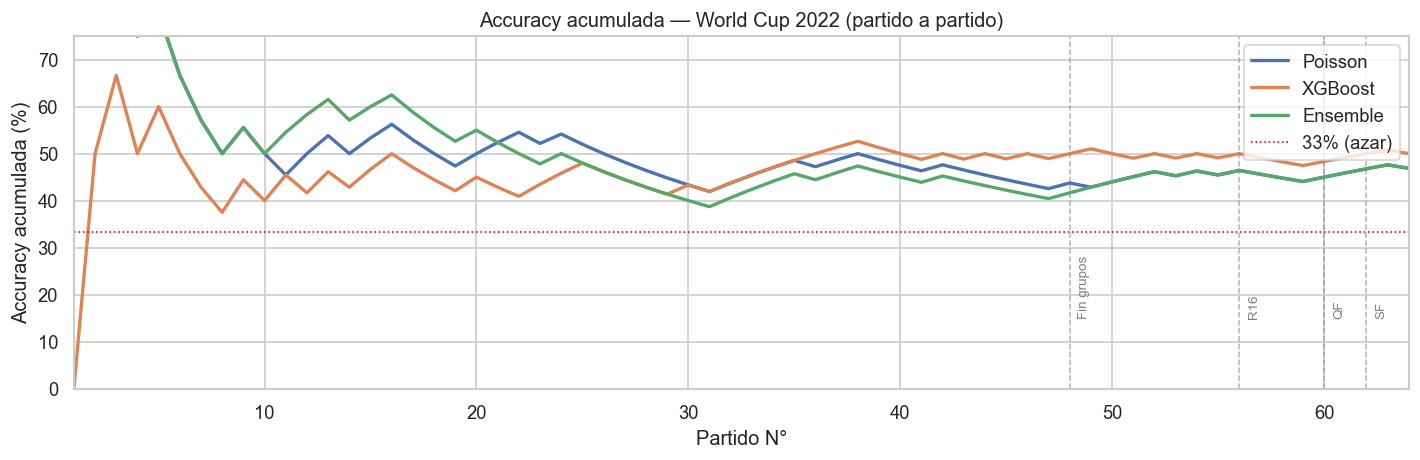

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))

model_colors = {'poisson': '#4c72b0', 'xgb': '#dd8452', 'ens': '#55a868'}
model_names  = {'poisson': 'Poisson', 'xgb': 'XGBoost', 'ens': 'Ensemble'}

for model, color in model_colors.items():
    correct = (results['actual_result'] == results[f'pred_{model}']).astype(int)
    ax.plot(range(1, len(results) + 1), correct.expanding().mean() * 100,
            color=color, lw=2, label=model_names[model])

# Phase boundaries
for label, x in [('Fin grupos', 48), ('R16', 56), ('QF', 60), ('SF', 62)]:
    ax.axvline(x, color='gray', ls='--', lw=0.9, alpha=0.6)
    ax.text(x + 0.4, 15, label, fontsize=8, color='gray', rotation=90, va='bottom')

ax.axhline(33.3, color='red', ls=':', lw=1, label='33% (azar)')
ax.set_title('Accuracy acumulada — World Cup 2022 (partido a partido)')
ax.set_xlabel('Partido N°')
ax.set_ylabel('Accuracy acumulada (%)')
ax.legend(loc='upper right')
ax.set_xlim(1, 64)
ax.set_ylim(0, 75)
plt.tight_layout()
plt.show()

## 7. Upsets — el modelo vs las sorpresas

In [11]:
# Partidos donde el ELO favorito perdio
UPSET_THRESHOLD = 50  # diferencia minima para considerar que habia favorito claro

clear_fav = results[results['elo_diff'].abs() > UPSET_THRESHOLD].copy()
# Upset = el favorito (mayor ELO) perdio
clear_fav['elo_fav_won'] = (
    ((clear_fav['elo_diff'] > 0) & (clear_fav['actual_result'] == 2)) |
    ((clear_fav['elo_diff'] < 0) & (clear_fav['actual_result'] == 0))
)
upsets = clear_fav[~clear_fav['elo_fav_won']].copy()

print(f"Partidos con favorito claro (|ELO diff| > {UPSET_THRESHOLD}): {len(clear_fav)}")
print(f"Upsets (favorito perdio): {len(upsets)}  ({len(upsets)/len(clear_fav):.0%})")
print()

if len(upsets) > 0:
    upsets['ens_ok'] = (upsets['actual_result'] == upsets['pred_ens']).map({True:'✓ detectado', False:'✗ no visto'})
    print(upsets[['date','home_team','away_team','home_score','away_score','elo_diff','ens_ok']].to_string(index=False))

Partidos con favorito claro (|ELO diff| > 50): 49
Upsets (favorito perdio): 21  (43%)

      date     home_team     away_team  home_score  away_score    elo_diff      ens_ok
2022-11-21 United States         Wales           1           1   56.522602  ✗ no visto
2022-11-22       Denmark       Tunisia           0           0  110.219977  ✗ no visto
2022-11-22     Argentina  Saudi Arabia           1           2  280.770270  ✗ no visto
2022-11-22        Mexico        Poland           0           0   83.350206  ✗ no visto
2022-11-23       Morocco       Croatia           0           0  -80.699603  ✗ no visto
2022-11-23       Germany         Japan           1           2   77.172111 ✓ detectado
2022-11-25       England United States           0           0   99.502757  ✗ no visto
2022-11-25   Netherlands       Ecuador           1           1  115.315289  ✗ no visto
2022-11-27         Spain       Germany           1           1   89.561898  ✗ no visto
2022-11-27       Belgium       Morocco     

In [12]:
## Resumen de hallazgos (auto-computado)
summary_rows = []
for model in ('poisson', 'xgb', 'ens'):
    m = compute_metrics(results, model)
    summary_rows.append({
        'Modelo':       {'poisson':'Poisson','xgb':'XGBoost','ens':'Ensemble'}[model],
        'Accuracy':     m['accuracy'],
        'Log-loss':     m['log_loss'],
        'Brier':        m['brier'],
        'Score exacto': m.get('exact_score_acc'),
        'MAE goles':    m.get('goal_mae'),
    })

summary = pd.DataFrame(summary_rows).set_index('Modelo')

display(
    summary.style
    .format({
        'Accuracy':     '{:.1%}',
        'Log-loss':     '{:.3f}',
        'Brier':        '{:.3f}',
        'Score exacto': lambda x: f'{x:.1%}' if pd.notna(x) else '—',
        'MAE goles':    lambda x: f'{x:.2f}' if pd.notna(x) else '—',
    })
    .background_gradient(subset=['Accuracy'], cmap='Greens', vmin=0.3, vmax=0.6)
    .background_gradient(subset=['Log-loss','Brier'], cmap='Reds_r', vmin=0.6, vmax=1.2)
    .set_properties(**{'font-size': '12px', 'text-align': 'center'})
)

,Accuracy,Log-loss,Brier,Score exacto,MAE goles
Modelo,,,,,
Poisson,46.9%,1.121,0.656,6.2%,0.97
XGBoost,50.0%,1.162,0.669,—,—
Ensemble,46.9%,1.107,0.646,—,—
